In [90]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("train.csv")
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


In [91]:

df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9800 non-null   int64  
 1   Order ID       9800 non-null   object 
 2   Order Date     9800 non-null   object 
 3   Ship Date      9800 non-null   object 
 4   Ship Mode      9800 non-null   object 
 5   Customer ID    9800 non-null   object 
 6   Customer Name  9800 non-null   object 
 7   Segment        9800 non-null   object 
 8   Country        9800 non-null   object 
 9   City           9800 non-null   object 
 10  State          9800 non-null   object 
 11  Postal Code    9789 non-null   float64
 12  Region         9800 non-null   object 
 13  Product ID     9800 non-null   object 
 14  Category       9800 non-null   object 
 15  Sub-Category   9800 non-null   object 
 16  Product Name   9800 non-null   object 
 17  Sales          9800 non-null   float64
dtypes: float

,Row ID,Postal Code,Sales
count,9800.000000,9789.000000,9800.000000
mean,4900.500000,55273.322403,230.769059
std,2829.160653,32041.223413,626.651875
min,1.000000,1040.000000,0.444000
25%,2450.750000,23223.000000,17.248000
50%,4900.500000,58103.000000,54.490000
75%,7350.250000,90008.000000,210.605000
max,9800.000000,99301.000000,22638.480000


In [92]:

df["Order Date"] = pd.to_datetime(df["Order Date"], format='mixed')
df["Ship Date"] = pd.to_datetime(df["Ship Date"], format='mixed')
df.isnull().sum()

df = df.dropna()

In [93]:

df['Year'] = df['Order Date'].dt.year
df['Month'] = df['Order Date'].dt.month
df['Delivery Time'] = (df['Ship Date'] - df['Order Date']).dt.days

df = df[df['Delivery Time'] >= 0]

df = df.reset_index(drop=True)

df.head(5)


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Year,Month,Delivery Time
0,1,CA-2017-152156,2017-08-11,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.960,2017,8,92
1,2,CA-2017-152156,2017-08-11,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.940,2017,8,92
2,13,CA-2018-114412,2018-04-15,2018-04-20,Standard Class,AA-10480,Andrew Allen,Consumer,United States,Concord,...,28027.0,South,OFF-PA-10002365,Office Supplies,Paper,Xerox 1967,15.552,2018,4,5
3,14,CA-2017-161389,2017-05-12,2017-10-12,Standard Class,IM-15070,Irene Maddox,Consumer,United States,Seattle,...,98103.0,West,OFF-BI-10003656,Office Supplies,Binders,Fellowes PB200 Plastic Comb Binding Machine,407.976,2017,5,153
4,15,US-2016-118983,2016-11-22,2016-11-26,Standard Class,HP-14815,Harold Pawlan,Home Office,United States,Fort Worth,...,76106.0,Central,OFF-AP-10002311,Office Supplies,Appliances,Holmes Replacement Filter for HEPA Air Cleaner...,68.810,2016,11,4


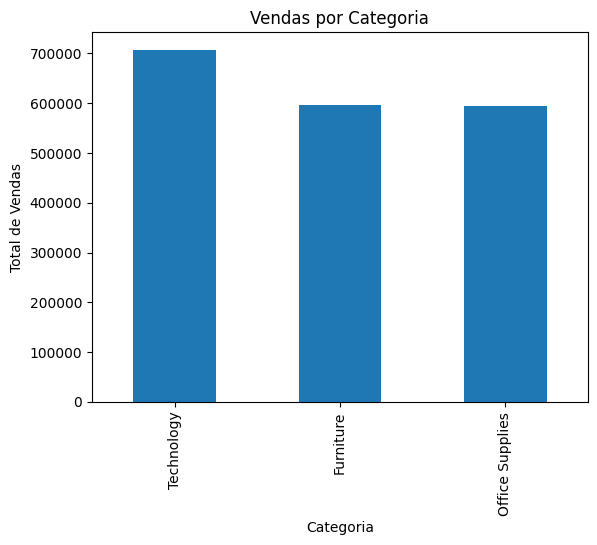

In [97]:
vendas_categoria = df.groupby('Category')['Sales'].sum().sort_values(ascending=False)
vendas_categoria.plot(kind='bar')

plt.title("Vendas por Categoria")
plt.xlabel("Categoria")
plt.ylabel("Total de Vendas")

plt.show()

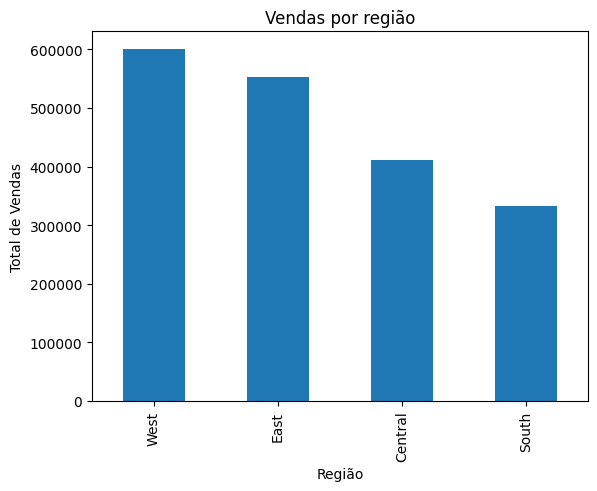

In [98]:
vendas_regiao = df.groupby('Region')['Sales'].sum().sort_values(ascending=False)
vendas_regiao.plot(kind='bar')

plt.title('Vendas por região')
plt.xlabel('Região')
plt.ylabel('Total de Vendas')

plt.show()

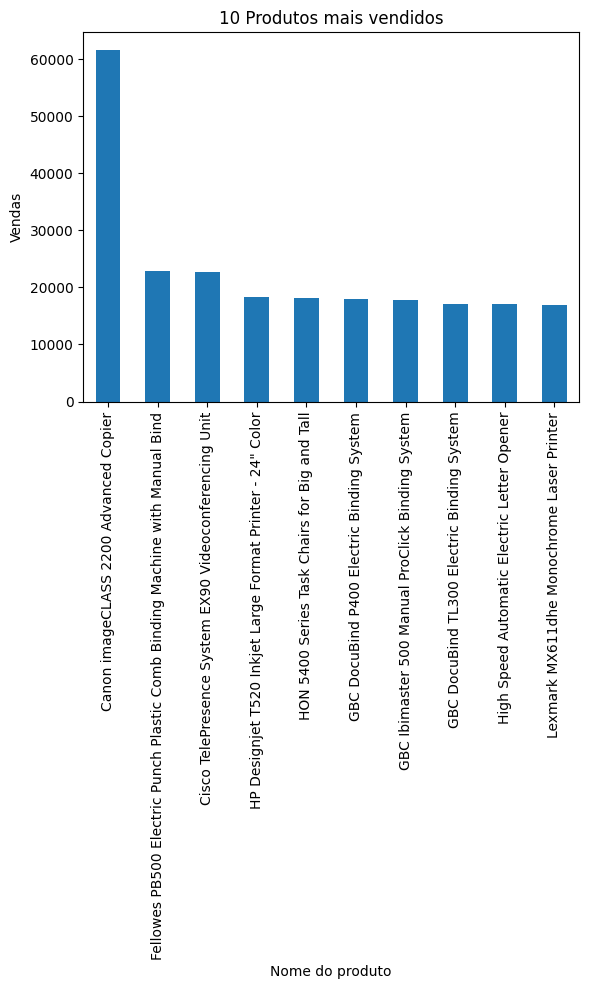

In [100]:
top_produtos = df.groupby('Product Name')['Sales'].sum().sort_values(ascending=False).head(10)
top_produtos.plot(kind='bar')

plt.title('10 Produtos mais vendidos')
plt.xlabel('Nome do produto')
plt.ylabel('Vendas')

plt.show()

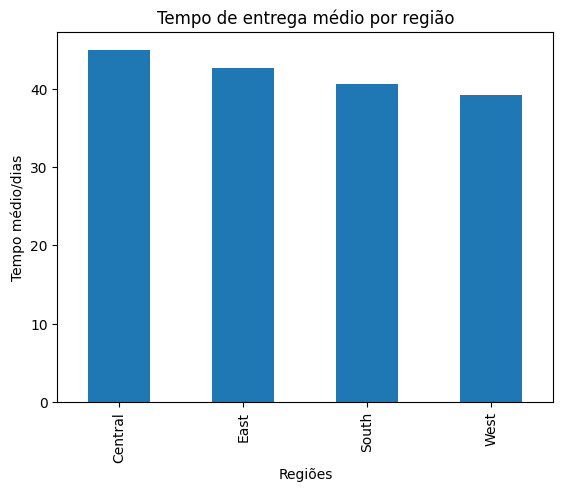

In [ ]:

delivery_by_region = df.groupby('Region')['Delivery Time'].mean()
delivery_by_region.plot(kind='bar')

plt.title('Tempo de entrega médio por região')
plt.xlabel('Regiões')
plt.ylabel('Tempo médio/dias')

plt.show()


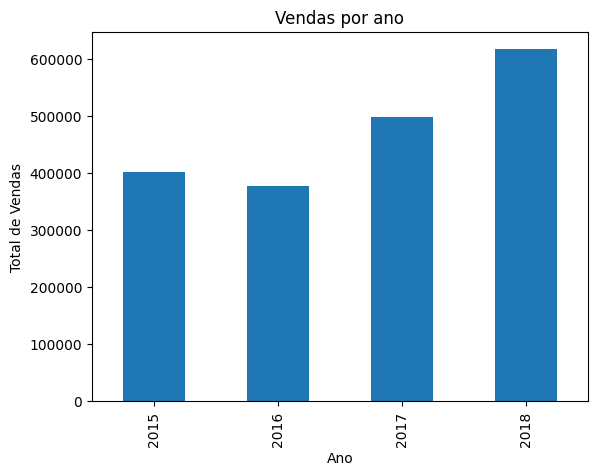

In [ ]:
vendas_ano = df.groupby('Year')['Sales'].sum()
vendas_ano.plot(kind='bar')

plt.title('Vendas por ano')
plt.xlabel('Ano')
plt.ylabel('Total de Vendas')

plt.show()

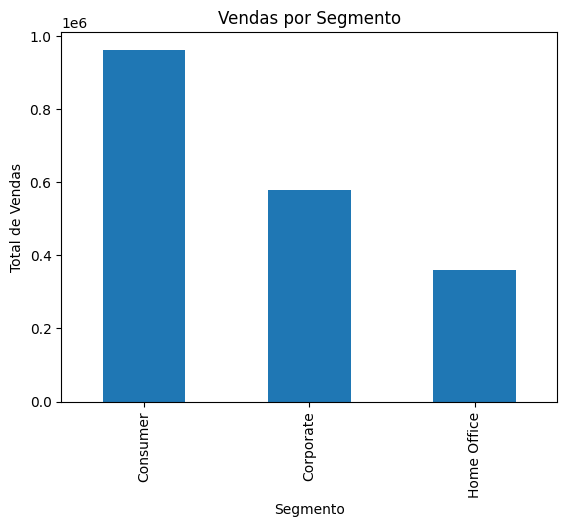

In [109]:
venda_segmen = df.groupby('Segment')['Sales'].sum().sort_values(ascending=False)
venda_segmen.plot(kind='bar')

plt.title('Vendas por Segmento')
plt.xlabel('Segmento')
plt.ylabel('Total de Vendas')

plt.show()

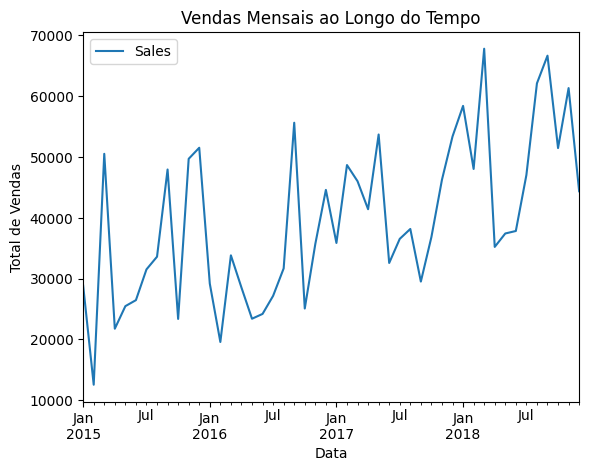

In [110]:
monthly_sales = df.groupby(['Year', 'Month'])['Sales'].sum().reset_index()
monthly_sales['Date'] = pd.to_datetime(monthly_sales['Year'].astype(str) + '-' + monthly_sales['Month'].astype(str) + '-01')
monthly_sales = monthly_sales.sort_values('Date')

monthly_sales.plot(x='Date', y='Sales', kind='line')

plt.title('Vendas Mensais ao Longo do Tempo')
plt.xlabel('Data')
plt.ylabel('Total de Vendas')

plt.show()

In [ ]:
## Key Insights

#- Technology is the top revenue category
#- West region leads total sales
#- Consumer segment generates most purchases
#- A small group of products concentrate revenue
#- Average delivery time is around 41 days
#- 2018 has the most sales (March was the best month)
